In [5]:
!pip install transformers datasets scikit-learn matplotlib seaborn

In [6]:
import pandas as pd
import numpy as np
import torch
import re

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import Trainer, TrainingArguments

In [7]:
dataset = load_dataset("imdb")

df = pd.DataFrame(dataset['train'])

# Reduce size for faster execution
df = df.sample(1000, random_state=42)

df.head()

,text,label
6868,"Dumb is as dumb does, in this thoroughly unint...",0
24016,I dug out from my garage some old musicals and...,1
9668,After watching this movie I was honestly disap...,0
13640,This movie was nominated for best picture but ...,1
14018,Just like Al Gore shook us up with his painful...,1


In [8]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

df['text'] = df['text'].apply(clean_text)

In [9]:
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['text'], df['label'], test_size=0.2, random_state=42
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=42
)

In [10]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize(texts):
    return tokenizer(
        list(texts),
        truncation=True,
        padding=True,
        max_length=64
    )

train_enc = tokenize(train_texts)
val_enc = tokenize(val_texts)
test_enc = tokenize(test_texts)

In [11]:
class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = CustomDataset(train_enc, train_labels)
val_dataset = CustomDataset(val_enc, val_labels)
test_dataset = CustomDataset(test_enc, test_labels)

In [12]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [13]:
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

Loading weights: 100%|████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 17557.47it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [14]:
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=1,
    eval_strategy="no",   # important fix
    logging_steps=100,
    save_strategy="no"
)

In [15]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

In [16]:
trainer.train()

C:\Users\kodur\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss


TrainOutput(global_step=50, training_loss=0.6824238586425782, metrics={'train_runtime': 83.1376, 'train_samples_per_second': 9.623, 'train_steps_per_second': 0.601, 'total_flos': 13246739865600.0, 'train_loss': 0.6824238586425782, 'epoch': 1.0})

In [17]:
output = trainer.predict(test_dataset)

preds = np.argmax(output.predictions, axis=1)
labels = output.label_ids

print("Accuracy:", accuracy_score(labels, preds))

Accuracy: 0.59


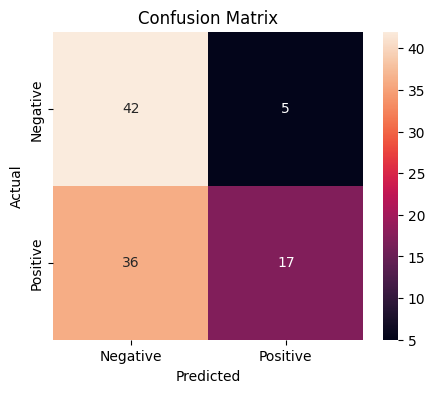

In [18]:
cm = confusion_matrix(labels, preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

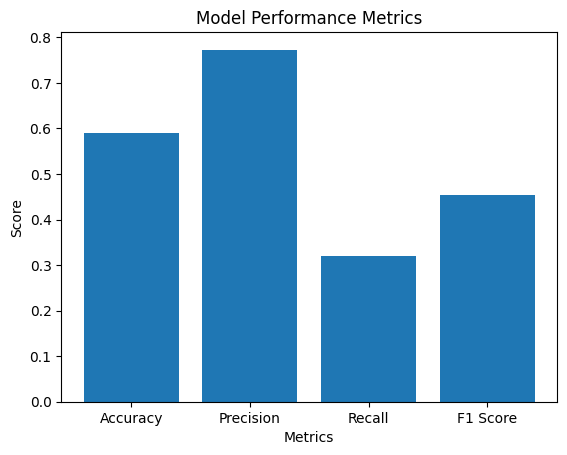

In [19]:
# Calculate metrics
precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
accuracy = accuracy_score(labels, preds)

# Store values
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy, precision, recall, f1]

# Plot graph
plt.figure()
plt.bar(metrics, values)
plt.title("Model Performance Metrics")
plt.xlabel("Metrics")
plt.ylabel("Score")
plt.show()